In [14]:
import os
import json
import random
import torch
import time
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.ops import MultiScaleRoIAlign
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Usando dispositivo: {device}")

class MultiTaskObjectDetectionDataset(Dataset):
    def __init__(self, image_dir, label_dir, transform=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.transform = transform

        with open("helpers/categories.json") as f:
            self.categories = json.load(f)
        with open("helpers/weather.json") as f:
            self.weather = json.load(f)
        with open("helpers/scene.json") as f:
            self.scene = json.load(f)
        with open("helpers/timeofday.json") as f:
            self.timeofday = json.load(f)

        self.image_ids = [f.split('.')[0] for f in os.listdir(image_dir)
                          if f.endswith(('.jpg', '.png')) and os.path.exists(os.path.join(label_dir, f.split('.')[0] + ".json"))]

        print(f"📸 Dataset carregado de {image_dir} com {len(self.image_ids)} imagens.")

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        try:
            image = Image.open(os.path.join(self.image_dir, image_id + ".jpg")).convert("RGB")
            with open(os.path.join(self.label_dir, image_id + ".json")) as f:
                data = json.load(f)
        except Exception as e:
            print(f"❌ Erro ao carregar {image_id}: {e}")
            return None

        boxes, labels = [], []
        for obj in data["frames"][0]["objects"]:
            category = obj.get("category")
            if category not in self.categories:
                continue
            bbox = None
            if "box2d" in obj:
                b = obj["box2d"]
                bbox = [b["x1"], b["y1"], b["x2"], b["y2"]]
            elif "poly2d" in obj:
                pts_raw = obj["poly2d"]
                if isinstance(pts_raw[0], dict) and "vertices" in pts_raw[0]:
                    pts = pts_raw[0]["vertices"]
                else:
                    pts = [(p[0], p[1]) for p in pts_raw if isinstance(p, (list, tuple)) and len(p) >= 2]
                if len(pts) >= 2:
                    xs, ys = zip(*pts)
                    bbox = [min(xs), min(ys), max(xs), max(ys)]
            if bbox and bbox[2] > bbox[0] and bbox[3] > bbox[1]:
                boxes.append(bbox)
                labels.append(self.categories[category])

        if not boxes:
            return None

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)
        target = {"boxes": boxes, "labels": labels}

        attrs = data["attributes"]
        global_attrs = {
            "weather": torch.tensor(self.weather.get(attrs["weather"], 0)),
            "scene": torch.tensor(self.scene.get(attrs["scene"], 0)),
            "timeofday": torch.tensor(self.timeofday.get(attrs["timeofday"], 0)),
        }

        if self.transform:
            image = self.transform(image)

        return image, target, global_attrs

🖥️ Usando dispositivo: cpu


In [15]:
def collate_fn(batch):
    valid = [b for b in batch if b is not None]
    return tuple(zip(*valid)) if valid else ([], [], [])


class MultiTaskModel(nn.Module):
    def __init__(self, detection_model, backbone, num_weather, num_scene, num_time):
        super().__init__()
        self.detector = detection_model
        self.backbone = backbone
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc_weather = nn.Linear(1280, num_weather)
        self.fc_scene = nn.Linear(1280, num_scene)
        self.fc_timeofday = nn.Linear(1280, num_time)

    def forward(self, images, targets=None, global_attrs=None):
        if self.training:
            det_loss = self.detector(images, targets)
        else:
            det_loss = {}
            _ = self.detector(images)

        features = self.backbone(torch.stack(images))
        pooled = self.pool(features).view(features.size(0), -1)
        w_logits = self.fc_weather(pooled)
        s_logits = self.fc_scene(pooled)
        t_logits = self.fc_timeofday(pooled)

        attr_loss = 0
        if self.training and global_attrs:
            w = torch.stack([a["weather"] for a in global_attrs])
            s = torch.stack([a["scene"] for a in global_attrs])
            t = torch.stack([a["timeofday"] for a in global_attrs])
            attr_loss = (F.cross_entropy(w_logits, w) +
                         F.cross_entropy(s_logits, s) +
                         F.cross_entropy(t_logits, t))

        return det_loss, attr_loss, w_logits, s_logits, t_logits

In [16]:
print("🔧 Inicializando MobileNetV2...")
mobilenet = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V2)
backbone = mobilenet.features
backbone.out_channels = 1280

anchor_gen = AnchorGenerator(sizes=((32, 64, 128, 256, 512),),
                             aspect_ratios=((0.5, 1.0, 2.0),))
roi_pool = MultiScaleRoIAlign(featmap_names=["0"], output_size=7, sampling_ratio=2)

transform = transforms.Compose([transforms.ToTensor()])
splits = {
    "train": ("images/train", "labels/train"),
    "val": ("images/val", "labels/val"),
    "test": ("images/test", "labels/test")
}

datasets, loaders = {}, {}
for split, (img_dir, lbl_dir) in splits.items():
    print(f"📂 Carregando dataset '{split}'...")
    ds = MultiTaskObjectDetectionDataset(img_dir, lbl_dir, transform)
    # Subamostrar 10% dos dados:
    subset_size = max(1, int(len(ds) * 0.10))
    indices = random.sample(range(len(ds)), subset_size)
    ds_subset = Subset(ds, indices)
    datasets[split] = ds_subset
    loaders[split] = DataLoader(ds_subset, batch_size=4, shuffle=(split == "train"),
                                collate_fn=collate_fn, num_workers=8)
    print(f"Utilizando {subset_size} de {len(ds)} imagens para o split '{split}' (10%).")

num_classes = len(ds.categories) + 1
num_weather = len(ds.weather)
num_scene = len(ds.scene)
num_time = len(ds.timeofday)

faster_rcnn = FasterRCNN(backbone, num_classes=num_classes,
                         rpn_anchor_generator=anchor_gen,
                         box_roi_pool=roi_pool).to(device)

multi_task_model = MultiTaskModel(faster_rcnn, backbone, num_weather, num_scene, num_time).to(device)
optimizer = torch.optim.SGD(multi_task_model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)

print("🚀 Iniciando treinamento...")
loss_history = []
for epoch in range(1, 11):
    multi_task_model.train()
    total_loss = 0
    epoch_start = time.time()
    total_batches = len(loaders["train"])
    print(f"Total de batches para a Epoch {epoch}: {total_batches}")
    for batch_idx, (images, targets, attrs) in enumerate(loaders["train"], start=1):
        batch_start = time.time()
        current_batch_size = len(images)
        print(f"📦 Epoch {epoch}, Batch {batch_idx}/{total_batches} com {current_batch_size} imagens.")
        if not images:
            continue

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        det_loss, attr_loss, *_ = multi_task_model(images, targets, attrs)
        loss = sum(det_loss.values()) + attr_loss
        loss.backward()
        optimizer.step()

        batch_time = time.time() - batch_start
        total_loss += loss.item()
        print(f"✅ Epoch {epoch}, Batch {batch_idx}: Loss = {loss.item():.4f}, Tempo do batch = {batch_time:.2f} s")
    epoch_time = time.time() - epoch_start
    loss_history.append(total_loss)
    print(f"🎯 Epoch {epoch} concluída em {epoch_time:.2f} s. Loss total: {total_loss:.4f}")

torch.save(multi_task_model, "multi_task_model_complete.pth")
print("💾 Modelo salvo como 'multi_task_model_complete.pth'")

🔧 Inicializando MobileNetV2...
📂 Carregando dataset 'train'...
📸 Dataset carregado de images/train com 7000 imagens.
Utilizando 700 de 7000 imagens para o split 'train' (10%).
📂 Carregando dataset 'val'...
📸 Dataset carregado de images/val com 1000 imagens.
Utilizando 100 de 1000 imagens para o split 'val' (10%).
📂 Carregando dataset 'test'...
📸 Dataset carregado de images/test com 2000 imagens.
Utilizando 200 de 2000 imagens para o split 'test' (10%).
🚀 Iniciando treinamento...
Total de batches para a Epoch 1: 175
📦 Epoch 1, Batch 1/175 com 4 imagens.
✅ Epoch 1, Batch 1: Loss = 9.1091, Tempo do batch = 14.51 s
📦 Epoch 1, Batch 2/175 com 4 imagens.
✅ Epoch 1, Batch 2: Loss = 8.3900, Tempo do batch = 14.32 s
📦 Epoch 1, Batch 3/175 com 4 imagens.
✅ Epoch 1, Batch 3: Loss = 8.3156, Tempo do batch = 14.96 s
📦 Epoch 1, Batch 4/175 com 4 imagens.
✅ Epoch 1, Batch 4: Loss = 7.2157, Tempo do batch = 17.07 s
📦 Epoch 1, Batch 5/175 com 4 imagens.
✅ Epoch 1, Batch 5: Loss = 6.0119, Tempo do batch

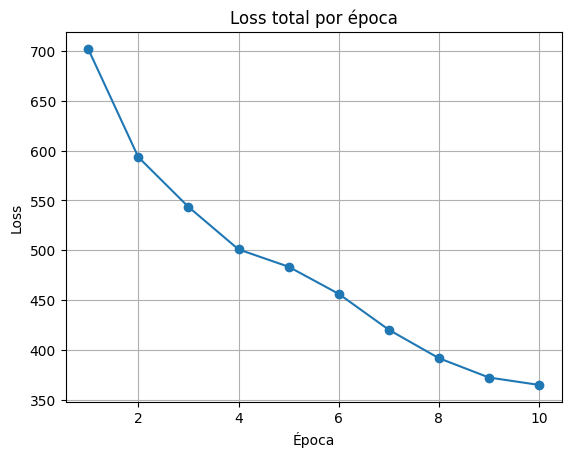

In [17]:
plt.plot(range(1, len(loss_history)+1), loss_history, marker='o')
plt.title("Loss total por época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [18]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter_area = max(0, x2 - x1) * max(0, y2 - y1)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0

def evaluate(model, loader, device, iou_threshold=0.5, confidence_threshold=0.6):
    """
    Evaluates the model on the given loader.
    Computes:
      - Global attribute accuracies (weather, scene, timeofday)
      - Detection category accuracy (comparing predicted labels with ground truth 
        for matched boxes using IoU threshold)
      - Average number of detections per image.
    """
    model.eval()
    total = 0
    correct_weather, correct_scene, correct_time = 0, 0, 0
    total_gt = 0      # Total ground truth boxes
    correct_category = 0  # Count of correctly predicted categories (for matched boxes)
    detections_count = 0  # Total number of detections (for matched boxes)
    
    with torch.no_grad():
        for images, targets, attrs in loader:
            if not images:
                continue
            images = [img.to(device) for img in images]

            # Get attribute predictions from the attribute branch
            _, _, w_logits, s_logits, t_logits = model(images)
            w_preds = torch.argmax(w_logits, dim=1).cpu()
            s_preds = torch.argmax(s_logits, dim=1).cpu()
            t_preds = torch.argmax(t_logits, dim=1).cpu()

            w_true = torch.stack([a["weather"] for a in attrs])
            s_true = torch.stack([a["scene"] for a in attrs])
            t_true = torch.stack([a["timeofday"] for a in attrs])

            correct_weather += (w_preds == w_true).sum().item()
            correct_scene += (s_preds == s_true).sum().item()
            correct_time += (t_preds == t_true).sum().item()
            total += len(images)

            # Evaluate detection category accuracy
            # Use the detection branch from the model:
            detections_batch = model.detector(images)
            for i, detection in enumerate(detections_batch):
                gt_boxes = targets[i]["boxes"].cpu().numpy()
                gt_labels = targets[i]["labels"].cpu().numpy()
                total_gt += len(gt_boxes)

                pred_boxes = detection["boxes"].cpu().numpy()
                pred_labels = detection["labels"].cpu().numpy()
                pred_scores = detection["scores"].cpu().numpy()

                # Filter predictions by confidence threshold
                keep = pred_scores >= confidence_threshold
                pred_boxes = pred_boxes[keep]
                pred_labels = pred_labels[keep]

                for j, gt_box in enumerate(gt_boxes):
                    best_iou = 0
                    best_idx = -1
                    for k, pred_box in enumerate(pred_boxes):
                        iou = compute_iou(gt_box, pred_box)
                        if iou > best_iou:
                            best_iou = iou
                            best_idx = k
                    if best_iou >= iou_threshold:
                        detections_count += 1
                        # Check if the predicted label matches the ground truth
                        if pred_labels[best_idx] == gt_labels[j]:
                            correct_category += 1

    weather_acc = correct_weather / total if total > 0 else 0
    scene_acc = correct_scene / total if total > 0 else 0
    time_acc = correct_time / total if total > 0 else 0
    detection_cat_acc = correct_category / total_gt if total_gt > 0 else 0
    avg_detections = detections_count / total if total > 0 else 0

    print(f"📊 Avaliação em {total} imagens:")
    print(f"🌤️ Acurácia Weather: {weather_acc:.2%}")
    print(f"🌆 Acurácia Scene:   {scene_acc:.2%}")
    print(f"🌙 Acurácia Time:    {time_acc:.2%}")
    print(f"📦 Média de detecções por imagem (matched): {avg_detections:.2f}")
    print(f"🎯 Acurácia de categorias: {detection_cat_acc:.2%}")

    return weather_acc, scene_acc, time_acc, avg_detections, detection_cat_acc
    
# Chamada do método de avaliação
weather_acc, scene_acc, time_acc, avg_detections, detection_cat_acc = evaluate(multi_task_model, loaders["val"], device, iou_threshold=0.5, confidence_threshold=0.6)

📊 Avaliação em 100 imagens:
🌤️ Acurácia Weather: 59.00%
🌆 Acurácia Scene:   65.00%
🌙 Acurácia Time:    60.00%
📦 Média de detecções por imagem (matched): 1.10
🎯 Acurácia de categorias: 6.67%


In [19]:
# Função para inverter um mapeamento
def invert_mapping(mapping):
    return {v: k for k, v in mapping.items()}

# Função para inferir e anotar uma única imagem
def infer_and_annotate_image(image_path, model, device, transform,
                             category_to_label, weather_to_label, 
                             scene_to_label, timeofday_to_label,
                             confidence_threshold=0.5):
    # Constrói os mapeamentos inversos para converter as predições numéricas em rótulos legíveis
    inv_category = invert_mapping(category_to_label)
    inv_weather = invert_mapping(weather_to_label)
    inv_scene = invert_mapping(scene_to_label)
    inv_timeofday = invert_mapping(timeofday_to_label)

    # Carrega e transforma a imagem
    orig_image = Image.open(image_path).convert("RGB")
    input_image = transform(orig_image).to(device)
    input_image = input_image.unsqueeze(0)  # Adiciona dimensão de batch

    model.eval()
    with torch.no_grad():
        # Obtém as detecções usando a branch de detecção
        detections = model.detector([input_image.squeeze(0)])
        # Obtém as predições globais de atributos usando a branch de atributos
        feats = model.backbone(input_image)
        pooled = model.pool(feats)
        pooled = pooled.view(pooled.size(0), -1)
        weather_logits = model.fc_weather(pooled)
        scene_logits = model.fc_scene(pooled)
        timeofday_logits = model.fc_timeofday(pooled)

        weather_pred = int(torch.argmax(weather_logits, dim=1).item())
        scene_pred = int(torch.argmax(scene_logits, dim=1).item())
        timeofday_pred = int(torch.argmax(timeofday_logits, dim=1).item())

        global_attributes = {
            "weather": inv_weather.get(weather_pred, str(weather_pred)),
            "scene": inv_scene.get(scene_pred, str(scene_pred)),
            "timeofday": inv_timeofday.get(timeofday_pred, str(timeofday_pred))
        }

        # Processa as detecções para a imagem
        detection = detections[0]
        boxes = detection["boxes"].cpu().numpy().tolist()
        labels = detection["labels"].cpu().numpy().tolist()
        scores = detection["scores"].cpu().numpy().tolist()

        detection_list = []
        for bbox, label, score in zip(boxes, labels, scores):
            if score < confidence_threshold:
                continue
            detection_list.append({
                "category": inv_category.get(label, str(label)),
                "score": score,
                "box": bbox
            })

    # Anota a imagem original com as detecções
    draw = ImageDraw.Draw(orig_image)
    try:
        font = ImageFont.truetype("arial.ttf", 15)
    except Exception:
        font = ImageFont.load_default()

    for det in detection_list:
        bbox = det["box"]
        text = f"{det['category']}: {det['score']:.2f}"
        draw.rectangle(bbox, outline="red", width=2)
        draw.text((bbox[0], bbox[1]-10), text, fill="red", font=font)
    # Anota os atributos globais no canto superior esquerdo
    attr_text = f"Weather: {global_attributes['weather']}, Scene: {global_attributes['scene']}, Time: {global_attributes['timeofday']}"
    draw.text((10, 10), attr_text, fill="blue", font=font)

    # Cria um dicionário com a saída
    output = {
        "global_attributes": global_attributes,
        "detections": detection_list
    }
    return orig_image, output

# Função para inferir todas as imagens de um diretório de teste
def infer_on_test_folder(test_folder, output_folder, model, device, transform,
                          category_to_label, weather_to_label, scene_to_label, timeofday_to_label,
                          confidence_threshold=0.5):
    os.makedirs(output_folder, exist_ok=True)
    results = {}
    for filename in os.listdir(test_folder):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_path = os.path.join(test_folder, filename)
            # Inferência para cada imagem
            annotated_img, output = infer_and_annotate_image(
                image_path, model, device, transform,
                category_to_label, weather_to_label, scene_to_label, timeofday_to_label,
                confidence_threshold
            )
            # Define caminhos de saída baseados no nome do arquivo
            base_name = os.path.splitext(filename)[0]
            annotated_image_path = os.path.join(output_folder, f"{base_name}_annotated.jpg")
            json_output_path = os.path.join(output_folder, f"{base_name}.json")
            annotated_img.save(annotated_image_path)
            with open(json_output_path, "w") as f:
                json.dump(output, f, indent=2)
            print(f"Processado: {filename}")
            results[filename] = output
    return results

# Carrega os mapeamentos
with open('helpers/categories.json', 'r') as f:
    category_to_label = json.load(f)
with open('helpers/weather.json', 'r') as f:
    weather_to_label = json.load(f)
with open('helpers/scene.json', 'r') as f:
    scene_to_label = json.load(f)
with open('helpers/timeofday.json', 'r') as f:
    timeofday_to_label = json.load(f)

# Define o dispositivo e a transformação
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([transforms.ToTensor()])

# Carrega o modelo completo (salvo anteriormente) para inferência
model = torch.load("multi_task_model_complete.pth", map_location=device, weights_only=False)
model.eval()
print("Modelo carregado e pronto para inferência.")

# Define o diretório de teste e o diretório de saída para as imagens anotadas e JSONs
test_folder = "images/test"
output_folder = "inference_outputs"

results = infer_on_test_folder(test_folder, output_folder, model, device, transform,
                               category_to_label, weather_to_label, scene_to_label, timeofday_to_label,
                               confidence_threshold=0.5)
print("Inferência concluída. Resultados:")
print(json.dumps(results, indent=2))


Modelo carregado e pronto para inferência.
Processado: cabe1040-5f02711e.jpg
Processado: cac07407-951977c8.jpg
Processado: cac07407-ba37148a.jpg
Processado: cac07407-e969f06a.jpg
Processado: cad4a646-68a8d136.jpg
Processado: cad7fdff-d9946f73.jpg
Processado: cadd00a0-efef6501.jpg
Processado: cae6c88d-0db9c3ab.jpg
Processado: caf8496d-6ce3dbda.jpg
Processado: caf92153-cfcdf92a.jpg
Processado: cafb3e6f-22f2007e.jpg
Processado: cafbae4e-1d69e770.jpg
Processado: cafbb9cb-c8d8b9df.jpg
Processado: caff2200-238a0388.jpg
Processado: caff5d9a-35754dcf.jpg
Processado: cb0ad251-7f86477e.jpg
Processado: cb146e98-77442601.jpg
Processado: cb14e978-6c4d53f3.jpg
Processado: cb14e978-a5eb5afb.jpg
Processado: cb16478b-2c1ed614.jpg
Processado: cb25d8ec-e52ef234.jpg
Processado: cb2fe290-7246a85f.jpg
Processado: cb32ab44-e8b00418.jpg
Processado: cb37bfff-1b87d685.jpg
Processado: cb3f27ee-b8c0119f.jpg
Processado: cb421747-f06aec7d.jpg
Processado: cb58f48b-957bfd2c.jpg
Processado: cb63ddeb-c7aee033.jpg
Proce